In [ ]:
!git clone https://github.com/imagdau/Tutorials.git
!pip install mace-torch xtb nglview ipywidgets rdkit x3dase
!pip install git+https://github.com/imagdau/aseMolec@main
!pip install -U numpy==2.0
%cd Tutorials

Cloning into 'Tutorials'...
remote: Enumerating objects: 350, done.
remote: Counting objects: 100% (120/120), done.
remote: Compressing objects: 100% (85/85), done.
remote: Total 350 (delta 58), reused 93 (delta 35), pack-reused 230 (from 1)
Receiving objects: 100% (350/350), 34.19 MiB | 13.66 MiB/s, done.
Resolving deltas: 100% (166/166), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.9/21.9 MB 19.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.0/202.0 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 387.7/387.7 kB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Cloning https://github.com/imagdau/aseMolec (to revision main) to /tmp/pip-req-build-slcakee7
  Running command git clone --filter=blob:none --quiet https://github.com/imagdau/aseMolec /tmp/pip-req-build-slcakee7
  Resolved https://github.com/imagdau/aseMolec to commit cae83dc4e041acd77b7e2119243b1e034acfbc86
  Preparing metadata (setup.py) ... done
  Created wheel for aseMolec: filename=aseMolec-1.0.0-py3-none-any.whl size=23098 sha256=034088d7a6cb91a3668e4f1e73152efe112054e3b524158d43399319a0727ee4
  Stored in directory: /tmp/pip-ephem-wheel-cache-fxq9r_h7/wheels/ca/6f/01/da5e58aa073ca05b020188d712a41f42460a3adbc3e8135afe
Successfully built aseMolec
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.3/19.3 MB 108.4 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency res

/content/Tutorials


In [ ]:
#Active Learning: comparing predictions of the 3 models to get max variance frames. For these frames we will then compute the energy and forces using single point DFT calculations.

from IPython import get_ipython
from IPython.display import display
# %%
#Use the LAMMPS trajectory to compute energy for MODEL 2 and MODEL 3
import numpy as np
from ase.io import read
from ase import Atoms
from matplotlib import pyplot as plt
from mace.calculators import MACECalculator
import sys # Import the sys module


/usr/local/lib/python3.11/dist-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


/usr/local/lib/python3.11/dist-packages/mace/calculators/mace.py:143: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
/usr/local/lib/python3.11/dist-packages/mace/calculators/mace.py:143: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Running committee mace with 2 models
Using head Default out of ['Default']
No dtype selected, switching to float32 to match model dtype.
Reading custom LAMMPS trajectory...
Successfully read 10001 frames from trajectory
Computing energies with MACE models...
Processing frame 0/10001
Processing frame 10/10001
Processing frame 20/10001
Processing frame 30/10001
Processing frame 40/10001
Processing frame 50/10001
Processing frame 60/10001
Processing frame 70/10001
Processing frame 80/10001
Processing frame 90/10001
Processing frame 100/10001
Processing frame 110/10001
Processing frame 120/10001
Processing frame 130/10001
Processing frame 140/10001
Processing frame 150/10001
Processing frame 160/10001
Processing frame 170/10001
Processing frame 180/10001
Processing frame 190/10001
Processing frame 200/10001
Processing frame 210/10001
Processing frame 220/10001
Processing frame 230/10001
Processing frame 240/10001
Processing frame 250/10001
Processing frame 260/10001
Processing frame 270/10

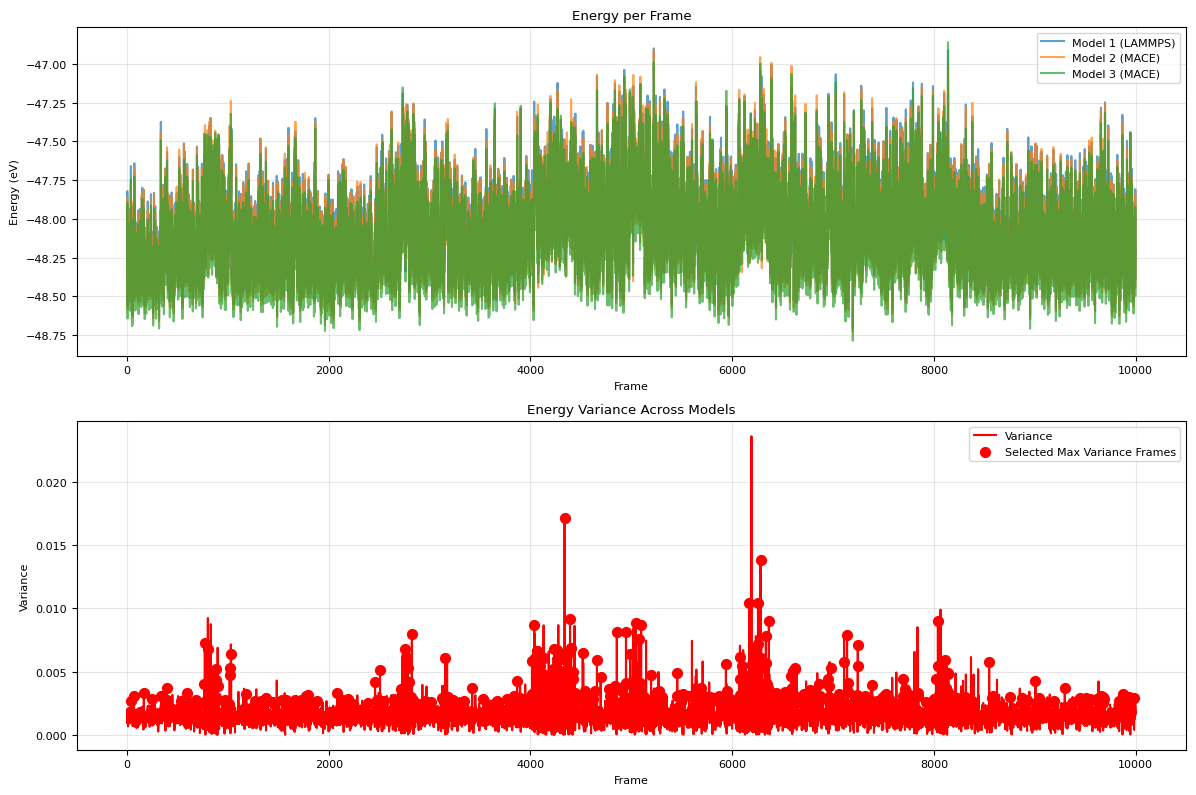


Saving high variance frames for active learning...


In [ ]:
def read_custom_lammps_trajectory(filename): #Reading the lammps trajectory files and extracting positions for every frames.

    atoms_list = []

    with open(filename, 'r') as f:
        lines = f.readlines()

    i = 0
    while i < len(lines):
        line = lines[i].strip()

        # Skip empty lines
        if not line:
            i += 1
            continue

        # Look for ITEM: TIMESTEP
        if line == "ITEM: TIMESTEP":
            timestep = int(lines[i+1].strip())
            i += 2
            continue

        # Look for ITEM: NUMBER OF ATOMS
        if line == "ITEM: NUMBER OF ATOMS":
            n_atoms = int(lines[i+1].strip())
            i += 2
            continue

        # Look for ITEM: BOX BOUNDS
        if line.startswith("ITEM: BOX BOUNDS"):
            # Read box bounds (3 lines)
            box_bounds = []
            for j in range(3):
                bounds = lines[i+1+j].strip().split()
                box_bounds.append([float(bounds[0]), float(bounds[1])])

            # Create cell matrix (assuming orthogonal box)
            cell = np.array([
                [box_bounds[0][1] - box_bounds[0][0], 0, 0],
                [0, box_bounds[1][1] - box_bounds[1][0], 0],
                [0, 0, box_bounds[2][1] - box_bounds[2][0]]
            ])
            i += 4
            continue

        # Look for ITEM: ATOMS
        if line.startswith("ITEM: ATOMS"):
            # Parse atom data
            positions = []
            types = []

            for j in range(n_atoms):
                atom_data = lines[i+1+j].strip().split()
                atom_id = int(atom_data[0])
                atom_type = int(atom_data[1])
                x = float(atom_data[2])
                y = float(atom_data[3])
                z = float(atom_data[4])
                # vx, vy, vz are in columns 5, 6, 7 but we don't need them for energy calculation

                positions.append([x, y, z])
                types.append(atom_type)

            # Convert to numpy array
            positions = np.array(positions)

            # Create ASE Atoms object
            # You need to map LAMMPS atom types to chemical symbols
            type_to_symbol = {
                1: 'Cl',
                2: 'Mo'
            }

            symbols = [type_to_symbol[t] for t in types]

            atoms = Atoms(symbols=symbols, positions=positions, cell=cell, pbc=True)
            atoms_list.append(atoms)

            i += n_atoms + 1
            continue

        i += 1

    return atoms_list

#Path for Model 2 and 3.
model_path = ["/content/3mo6cl_mace_run-15454.model","/content/3mo6cl_mace_run-16767.model"]
mace_calc = MACECalculator(model_path=model_path, device="cuda")


# Read the custom LAMMPS trajectory
print("Reading custom LAMMPS trajectory...")
try:
    traj = read_custom_lammps_trajectory("/content/spring_trajectory_3Mo6Cl.lammpstrj")
    print(f"Successfully read {len(traj)} frames from trajectory")
except Exception as e:
    print(f"Error reading trajectory: {e}")
    # Fallback: try standard ASE reader
    print("Trying standard ASE reader...")
    try:
        traj = read("/content/spring_trajectory_3Mo6Cl.lammpstrj", index=":")
        print(f"Successfully read {len(traj)} frames using ASE reader")
    except Exception as e2:
        print(f"ASE reader also failed: {e2}")
        sys.exit(1)

# compute the energy for corresponding frames in the trajectory for model 2 and 3
energies_model_2 = []
energies_model_3 = []

print("Computing energies with MACE models...")
for i, atoms in enumerate(traj):
    if i % 10 == 0:  # Progress indicator
        print(f"Processing frame {i}/{len(traj)}")

    atoms.calc = mace_calc
    try:
        # For multiple models, MACE returns energies for each model
        energy = atoms.get_potential_energies()

        # If you have multiple models, you might need to access them differently
        # Check MACE documentation for the exact API
        if isinstance(energy, (list, np.ndarray)) and len(energy) >= 2:
            energies_model_2.append(energy[0])
            energies_model_3.append(energy[1])
        else:
            # If single energy returned, you might need to calculate separately
            # This depends on how your MACE calculator is set up
            energies_model_2.append(energy)
            energies_model_3.append(energy)  # Placeholder - you may need to modify this

    except Exception as e:
        print(f"Error computing energy for frame {i}: {e}")
        continue


thermo_file = "/content/thermo_output_3Mo6Cl.txt"
energies_model_1 = []
start_timestep = 2000 # The timestep where your trajectory starts

print("Reading LAMMPS thermo output...")
with open(thermo_file, 'r') as f:
    # Skip header lines until you find the line starting with "Step"
    found_header = False
    for line in f:
        if line.strip().startswith("Step"):
            found_header = True
            break

    # Read energy data after the header, starting from the desired timestep
    if found_header:
      check_timestep = False
      for line in f:
            data = line.split()
            if len(data) > 2:
                try:
                    step = int(data[0]) # Assuming step is the first column
                    if step == start_timestep and check_timestep==False:
                        energy_model_1 = float(data[2]) # Assuming 'pe' is the third column
                        energies_model_1.append(energy_model_1)
                        check_timestep=True #only reads the start_timestep once.
                    if step > start_timestep:
                        energy_model_1 = float(data[2]) # Assuming 'pe' is the third column
                        energies_model_1.append(energy_model_1)
                except ValueError:
                    # Skip lines that don't have valid numerical data
                    pass

print(f"Model 1 energies: {len(energies_model_1)} points")
print(f"Model 2 energies: {len(energies_model_2)} points")
print(f"Model 3 energies: {len(energies_model_3)} points")

# Calculate variance for active learning
variances = []
for i in range(len(energies_model_1)):
    energies = [energies_model_1[i], energies_model_2[i], energies_model_3[i]]
    variance = np.var(energies) #computing variances.
    variances.append(variance)

# Find frames with maximum variance for active learning part.
max_variance_indices_all = np.argsort(variances)[-1000:]  # Top 1000 frames with highest variance

# Randomly select 500 indices from the top 1000 to minimize correlation between the frames.
np.random.seed(42)
max_variance_indices = np.random.choice(max_variance_indices_all, size=500, replace=False)

# Sort the indices in ascending order
max_variance_indices.sort()
print(f"Selected {len(max_variance_indices)} frames with highest variance: {max_variance_indices}")
print(f"Corresponding variances: {[variances[i] for i in max_variance_indices]}")

# plot the energies for all the 3 models
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(energies_model_1, label="Model 1 (LAMMPS)", alpha=0.7)
plt.plot(energies_model_2, label="Model 2 (MACE)", alpha=0.7)
plt.plot(energies_model_3, label="Model 3 (MACE)", alpha=0.7)
plt.xlabel("Frame")
plt.ylabel("Energy (eV)")
plt.title("Energy per Frame")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(variances, label="Variance", color='red')
plt.scatter(max_variance_indices, [variances[i] for i in max_variance_indices],
           color='red', s=50, zorder=5, label='Selected Max Variance Frames')
plt.xlabel("Frame")
plt.ylabel("Variance")
plt.title("Energy Variance Across Models")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Save high variance frames for active learning
print(f"\nSaving high variance frames for active learning...")
high_variance_atoms = [traj[i] for i in max_variance_indices]
# write("high_variance_frames.xyz", high_variance_atoms)
